<a href="https://colab.research.google.com/github/shreyesk-gif/CODSOFT-Data-Science/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('/content/Titanic-Dataset.csv')
print(df.head())
print(df.shape)

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
(8

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Survived
0    549
1    342
Name: count, dtype: int64
Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64


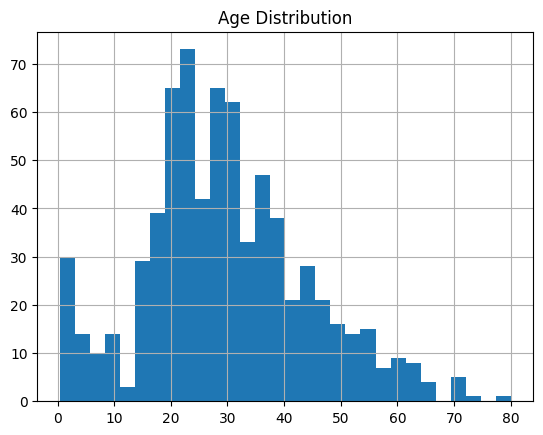

In [43]:
# Missing values
print(df.isnull().sum())
# Age: 177 missing Cabin: 687 missing Embarked: 2 missing

# Survival rate
print(df['Survived'].value_counts())
# 0 (died): 549  1 (survived): 342

# Survival by gender and class
print(df.groupby(['Sex', 'Pclass'])['Survived'].mean())

# Visualise age distribution
df['Age'].hist(bins=30)
plt.title('Age Distribution');
plt.show()

In [44]:
# Fill missing values (FIXED)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Encode categorical columns
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).fillna(0)
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  Sex   Age  SibSp  Parch  \
0                            Braund, Mr. Owen Harris    0  22.0      1      0   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...    1  38.0      1      0   
2                             Heikkinen, Miss. Laina    1  26.0      0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)    1  35.0      1      0   
4                           Allen, Mr. William Henry    0  35.0      0      0   

             Ticket     Fare Cabin  Embarked  
0         A/5 21171   7.2500   NaN         0  
1          PC 17599  71.2833   C85         1  
2  STON/O2. 3101282   7.9250   NaN         0  
3            113803  53.1000  C123         0  
4            373450   8.0500   NaN         0  


In [45]:
# 1. FamilySize — total family aboard
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# 2. IsAlone — travelling solo?
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# 3. Title — extract from Name (social status signal)
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(
    ['Lady','Countess','Capt','Col','Don','Dr',
     'Major','Rev','Sir','Jonkheer','Dona'], 'Rare')
df['Title'] = df['Title'].replace({'Mlle':'Miss','Ms':'Miss','Mme':'Mrs'})
title_map = {'Mr':1, 'Miss':2, 'Mrs':3, 'Master':4, 'Rare':5}
df['Title'] = df['Title'].map(title_map).fillna(0)

In [46]:
# Select final features
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
             'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title']

X = df[features]
y = df['Survived']

# Train-test split (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape)  # → (712, 10)
print(X_test.shape)   # → (179, 10)

(712, 10)
(179, 10)


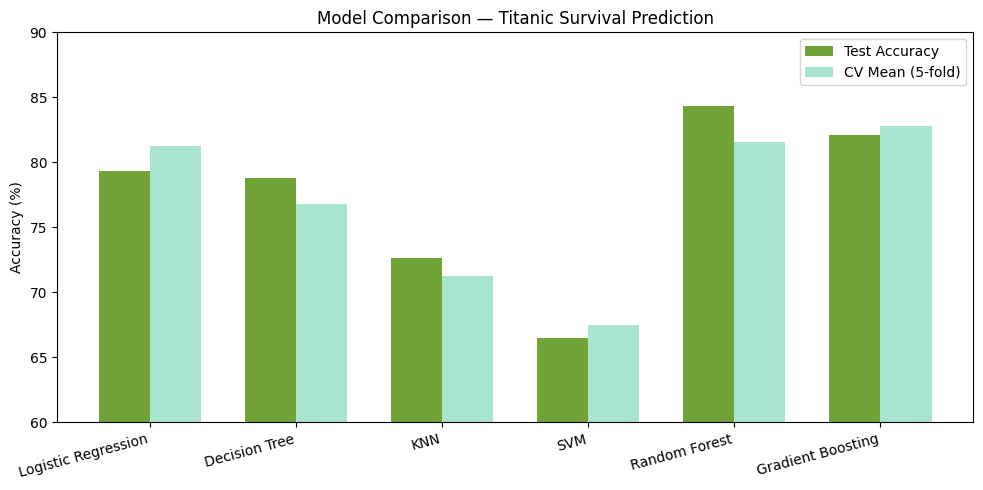

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "KNN":                 KNeighborsClassifier(),
    "SVM":                 SVC(random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

names, test_scores, cv_scores = [], [], []

for name, m in models.items():
    m.fit(X_train, y_train)
    test_scores.append(accuracy_score(y_test, m.predict(X_test)) * 100)
    cv_scores.append(cross_val_score(m, X, y, cv=5).mean() * 100)
    names.append(name)

# Plot
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, test_scores, width, label='Test Accuracy', color='#639922', alpha=0.9)
ax.bar(x + width/2, cv_scores,   width, label='CV Mean (5-fold)', color='#9FE1CB', alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(60, 90)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Model Comparison — Titanic Survival Prediction')
ax.legend()
plt.tight_layout()
plt.show()

Accuracy: 0.8435754189944135

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.88      0.87       105
           1       0.82      0.80      0.81        74

    accuracy                           0.84       179
   macro avg       0.84      0.84      0.84       179
weighted avg       0.84      0.84      0.84       179


Cross Validation Scores: [0.81564246 0.79775281 0.86516854 0.7752809  0.8258427 ]
Mean CV Accuracy: 0.816 ± 0.030


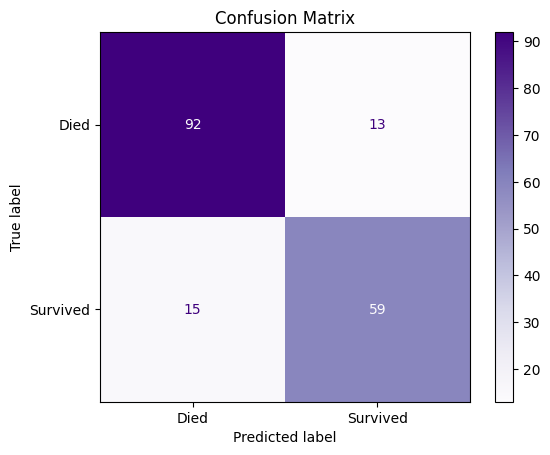

In [48]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score

# Model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict
preds = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, preds))

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# Cross Validation
cv = cross_val_score(model, X, y, cv=5)

print("\nCross Validation Scores:", cv)
print(f"Mean CV Accuracy: {cv.mean():.3f} ± {cv.std():.3f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = ConfusionMatrixDisplay(confusion_matrix(y_test, preds), display_labels=["Died", "Survived"])
cm.plot(cmap="Purples")
plt.title("Confusion Matrix")
plt.show()

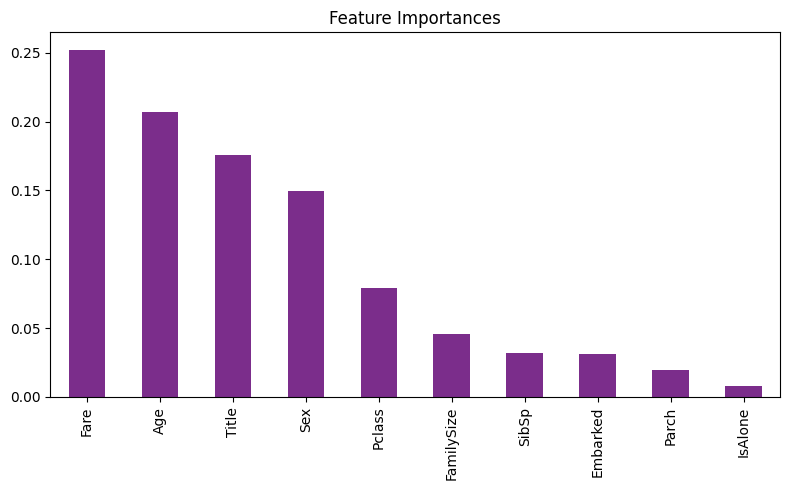

In [49]:
importances = pd.Series(
    model.feature_importances_, index=features
).sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances.plot(kind='bar', color='#7b2d8b')
plt.title('Feature Importances')
plt.tight_layout(); plt.show()

In [50]:
# New passenger: 3rd class male, age 25, alone, fare 7.25
new_passenger = pd.DataFrame([{
    'Pclass': 3, 'Sex': 0, 'Age': 25, 'SibSp': 0, 'Parch': 0,
    'Fare': 7.25, 'Embarked': 0, 'FamilySize': 1,
    'IsAlone': 1, 'Title': 1   # Title 1 = Mr
}])

prediction = model.predict(new_passenger)[0]
probability = model.predict_proba(new_passenger)[0]
print("Survived:", prediction)          # → 0 (did not survive)
print("Probability:", probability)      # → [0.82, 0.18]

prediction = model.predict(new_passenger)[0]
probability = model.predict_proba(new_passenger)[0]

# Clean output
if prediction == 0:
    print("Prediction: Did NOT Survive")
else:
    print("Prediction: Survived")

print(f"Probability Died: {probability[0]:.2f}, Survived: {probability[1]:.2f}")

Survived: 0
Probability: [0.95 0.05]
Prediction: Did NOT Survive
Probability Died: 0.95, Survived: 0.05


In [51]:
import joblib

# Save model to file
joblib.dump(model, 'titanic_model.pkl')

# Load it later
loaded_model = joblib.load('titanic_model.pkl')